In [49]:
import cv2
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# 🎯 Purporse project

* ### 1. Add Dataframe (df) features to ensure the LLM prompting is relevant to dataframe

* ### 2. Integration PDF report to dataframe for as reliable chatbot

* ### 3. Match recommendation system toward the images for where the product will be shown in UI as ranking recommendation

* ### 4. Merge LSTM model for sales and profit_status prediction (Optional)

## Load images dataset

In [50]:
from PIL import Image

IMAGE_DIR = "../../../fashion_images/dataset_clean"

images = []
image_paths = []

# iterate to call images data
for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        if filename.lower().endswith(".jpg"):
            path = os.path.join(root, filename)
            image = Image.open(path).convert("RGB")
            images.append(image)
            image_paths.append(path)
    
print(f"Loaded {len(images)} JPG Images")

Loaded 8625 JPG Images


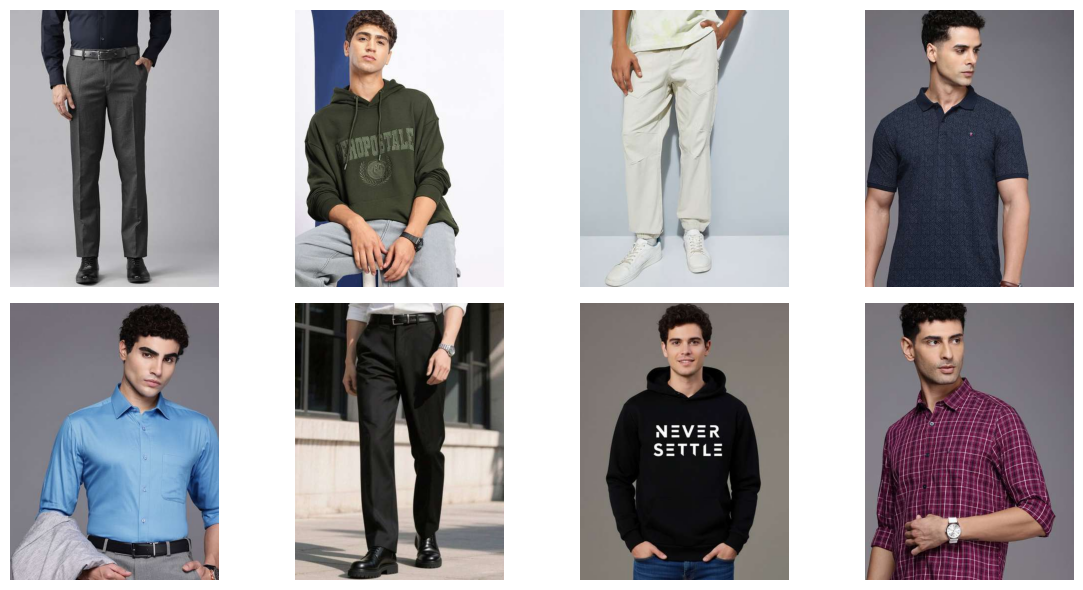

In [51]:
# Show random images

import random
import matplotlib.pyplot as plt

def show_random_images(images, n=8, cols=4, figsize=(12, 6)):
    n = min(n, len(images))
    selected = random.sample(images, n)

    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Usage
show_random_images(images, n=8)

## Load dataset

In [52]:
# Load parquet images dataset
df_images = pd.read_parquet("../../../data/matched_fashion_dataset.parquet")

# Load dataframes
df = pd.read_parquet("../../../MLOps/database/data/raw/matched_fashion_balance_rows_prediction.parquet")

## Load repot anaylsis PDF

In [53]:
# ============================================================
# CELL 1 — Install dependencies (run once)
# ============================================================
# !pip install langchain langchain-community pypdf -q


# ============================================================
# CELL 2 — Load PDF with LangChain
# ============================================================
from langchain_community.document_loaders import PyPDFLoader

PDF_DIR = "../../../pipelines/ai_engineer/docs/RAG_Analysis_Report.pdf"
loader = PyPDFLoader(PDF_DIR)
pages = loader.load_and_split()

print(f"✅ Loaded {len(pages)} pages from PDF")


# ============================================================
# CELL 3 — Display as Styled RAG Report UI in Notebook
# ============================================================
from IPython.display import display, HTML
import re
from datetime import datetime

# ── helpers ──────────────────────────────────────────────────

def extract_meta(pages):
    """Pull title, date, subject, preparer from first page text."""
    text = pages[0].page_content if pages else ""
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    # Date
    date_match = re.search(
        r"(January|February|March|April|May|June|July|August|"
        r"September|October|November|December)\s+\d{1,2},?\s+\d{4}", text, re.I
    )
    date = date_match.group(0) if date_match else datetime.today().strftime("%B %d, %Y")

    # Title — longest short line on page 1
    title_candidates = [l for l in lines if 8 < len(l) < 80]
    title = title_candidates[0] if title_candidates else "RAG Analysis Report"

    # Subject — second candidate
    subject = title_candidates[1] if len(title_candidates) > 1 else "Business Intelligence"

    # Prepared by
    prep = re.search(r"Prepared\s+by[:\s]+([^\n]+)", text, re.I)
    prepared_by = prep.group(1).strip() if prep else "Intelligence Team"

    # Classification
    cls = re.search(r"Classification[:\s]+([^\n]+)", text, re.I)
    classification = cls.group(1).strip() if cls else "Confidential — Internal Use Only"

    return dict(title=title, subject=subject, date=date,
                prepared_by=prepared_by, classification=classification)


def build_toc(pages):
    """Extract Q1/Q2 style headings or first line per page for TOC."""
    toc = []
    seen = set()
    for i, page in enumerate(pages):
        for line in page.page_content.split("\n"):
            line = line.strip()
            if re.match(r"^Q\d+[\.\)]", line, re.I) or re.match(r"^\d+[\.\)]\s+[A-Z]", line):
                short = line[:70] + ("..." if len(line) > 70 else "")
                if short not in seen:
                    seen.add(short)
                    toc.append((short, i + 1))
    if not toc:
        for i, page in enumerate(pages[:8]):
            first = next((l.strip() for l in page.page_content.split("\n") if l.strip()), "")
            short = first[:70] + ("..." if len(first) > 70 else "")
            toc.append((short, i + 1))
    return toc[:10]


def render_report(pages):
    """Render full styled RAG Report HTML inside a Jupyter cell."""
    meta   = extract_meta(pages)
    toc    = build_toc(pages)

    # ── TOC rows ──────────────────────────────────────────────
    toc_rows = "".join(
        f'<div class="toc-item">{item}'
        f'<span class="toc-pg">p.{pg}</span></div>'
        for item, pg in toc
    )
    toc_rows += '<div class="toc-item">Appendix A. Results Summary Table</div>'

    # ── Page sections ─────────────────────────────────────────
    page_sections = ""
    for i, page in enumerate(pages):
        safe = (page.page_content
                .replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;"))
        page_sections += f"""
        <div class="page-card">
            <div class="page-label">Page {i+1} of {len(pages)}</div>
            <div class="page-text">{safe}</div>
        </div>"""

    # ── Full HTML ─────────────────────────────────────────────
    html = f"""
    <div id="rag-report">
    <style>
        #rag-report {{
            font-family: Arial, sans-serif;
            background: #f0f4f8;
            padding: 0 0 40px 0;
            color: #1a1a2e;
        }}
        #rag-report .top-bar {{
            background: #0d1b3e;
            color: #fff;
            padding: 11px 32px;
            display: flex;
            justify-content: space-between;
            font-size: 13px;
            font-weight: bold;
            letter-spacing: .5px;
            border-bottom: 3px solid #2563eb;
        }}
        #rag-report .wrapper {{
            max-width: 900px;
            margin: 0 auto;
            padding: 36px 20px;
        }}
        #rag-report .hero {{
            background: #0d1b3e;
            border-radius: 8px;
            padding: 50px 48px;
            margin-bottom: 22px;
            text-align: center;
        }}
        #rag-report .hero h1 {{
            color: #fff;
            font-size: 50px;
            font-weight: 900;
            margin: 0;
            letter-spacing: -1px;
        }}
        #rag-report .meta-box {{
            background: linear-gradient(135deg,#2563eb,#3b82f6);
            border-radius: 8px;
            padding: 30px 48px;
            margin-bottom: 30px;
            text-align: center;
            color: #fff;
        }}
        #rag-report .meta-box .meta-title {{
            font-size: 21px;
            font-weight: 600;
            margin-bottom: 10px;
        }}
        #rag-report .meta-box .meta-item {{
            font-size: 14px;
            opacity: .82;
            margin: 3px 0;
        }}
        #rag-report hr.divider {{
            border: none;
            border-top: 2px solid #2563eb;
            margin: 28px 0 22px;
        }}
        #rag-report .section-title {{
            color: #0d1b3e;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 10px;
        }}
        #rag-report .exec-summary {{
            background: #dbeafe;
            border-radius: 6px;
            padding: 18px 22px;
            font-size: 14.5px;
            line-height: 1.75;
            text-align: justify;
            margin-bottom: 28px;
        }}
        #rag-report .exec-summary strong {{ color: #0d1b3e; }}
        #rag-report .toc-title {{
            color: #2563eb;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 8px;
        }}
        #rag-report .toc-item {{
            font-size: 13.5px;
            padding: 5px 0;
            border-bottom: 1px solid #e2e8f0;
            color: #1e293b;
        }}
        #rag-report .toc-pg {{
            float: right;
            color: #94a3b8;
            font-size: 12px;
        }}
        #rag-report .page-card {{
            background: #fff;
            border-radius: 8px;
            padding: 24px 28px;
            margin-bottom: 20px;
            box-shadow: 0 2px 8px rgba(0,0,0,.07);
            border-left: 4px solid #2563eb;
        }}
        #rag-report .page-label {{
            color: #2563eb;
            font-size: 11px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 1.5px;
            margin-bottom: 8px;
        }}
        #rag-report .page-text {{
            font-size: 13.5px;
            line-height: 1.75;
            color: #334155;
            white-space: pre-wrap;
            word-break: break-word;
        }}
    </style>

    <!-- Top bar -->
    <div class="top-bar">
        <span>RAG ANALYSIS REPORT &nbsp;|&nbsp; {meta['subject'].upper()}</span>
        <span>{meta['date']}</span>
    </div>

    <div class="wrapper">

        <!-- Hero -->
        <div class="hero">
            <h1>{meta['title']}</h1>
        </div>

        <!-- Meta -->
        <div class="meta-box">
            <div class="meta-title">{meta['subject']}</div>
            <div class="meta-item">Report Date: {meta['date']}</div>
            <div class="meta-item">Total Questions Analyzed: {len(pages)}</div>
            <div class="meta-item">Prepared by: {meta['prepared_by']}</div>
            <div class="meta-item">Classification: {meta['classification']}</div>
        </div>

        <hr class="divider">

        <!-- Executive Summary -->
        <div class="section-title">Executive Summary</div>
        <div class="exec-summary">
            This report presents comprehensive findings from
            <strong>{len(pages)} key pages</strong> analyzed using RAG
            (Retrieval-Augmented Generation) technology. The analysis leverages
            advanced machine learning and dynamic pricing research from peer-reviewed
            IEEE Access publications to provide evidence-based strategic insights for
            e-commerce revenue optimization, customer acquisition, sales forecasting,
            and deep learning applications.
        </div>

        <hr class="divider">

        <!-- Table of Contents -->
        <div class="toc-title">Table of Contents</div>
        <div style="margin-bottom:28px">{toc_rows}</div>

        <hr class="divider">

        <!-- Pages -->
        {page_sections}

    </div>
    </div>
    """
    display(HTML(html))


# ── Run ───────────────────────────────────────────────────────
render_report(pages)

✅ Loaded 7 pages from PDF


## Feature engineering dataframes

* ### Define dir images for ensure the images is exists
* ### Attached df_images -> df (dataframe merged conceptual)

In [54]:
image_dir = "../../../fashion_images/dataset_clean"
from pathlib import Path

# Load data but don't as list
image_list = Path(image_dir).rglob("*.jpg")
image_list = list(image_list)  # Convert generator to list for indexing
image_list[:5]

[PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg')]

In [55]:
image_paths_label = [
    {
       "image_path" : str(p).replace("../../../", ""),
        "filename"   : p.name,
        "category"   : p.parent.name
    }
    for p in image_list
]

image_paths_label[:5]

[{'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
  'filename': 'img_0969.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
  'filename': 'img_0955.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
  'filename': 'img_0799.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
  'filename': 'img_0941.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
  'filename': 'img_0772.jpg',
  'category': 'formal_shirts'}]

In [56]:
from pathlib import Path

# Define images_path based on category folders in image_paths

for item in image_paths[:10]:
    item_fashion = str(Path(item).name)
    item_class = str(Path(item).parent.name)
    print(item_fashion, item_class)

img_0969.jpg formal_shirts
img_0955.jpg formal_shirts
img_0799.jpg formal_shirts
img_0941.jpg formal_shirts
img_0772.jpg formal_shirts
img_0014.jpg formal_shirts
img_0766.jpg formal_shirts
img_0996.jpg formal_shirts
img_0028.jpg formal_shirts
img_0982.jpg formal_shirts


In [57]:
image_paths_df_images = df_images['image_path'].iloc[:len(df)].reset_index(drop=True) # Define image_paths here before attaching to df
subcategory_paths_df_images = df_images['subcategory'].iloc[:len(df)].reset_index(drop=True) # Define subcategory_paths here before attaching to df
category_paths_df_images = df_images['category'].iloc[:len(df)].reset_index(drop=True) # Define category_paths here before attaching to df

# Attach to df
df_merged = df.copy()
df_merged['image_path'] = image_paths_df_images
df_merged['subcategory'] = subcategory_paths_df_images
df_merged['category'] = category_paths_df_images

print(f"Merged shape:         {df_merged.shape}")          # 298,150
print(f"Missing image_path:   {df_merged['image_path'].isna().sum()}")  # should be 0
print(df_merged[['item_id', 'image_path']].head())

Merged shape:         (298150, 16)
Missing image_path:   0
       item_id                                         image_path
0  item_000001  ../fashion_images/dataset_clean/men_cargos/img...
1  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
2  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
3  item_000001  ../fashion_images/dataset_clean/printed_tshirt...
4  item_000001  ../fashion_images/dataset_clean/formal_shirts/...


In [58]:
# Fix paths for diplay on df_merged
df_merged['image_path'] = list(df_merged['image_path'].apply(lambda x: str(x).replace("../", "../../../")))
df_merged.head()

,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit,image_path,subcategory,category
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.0,60.195342,17.229404,127866.250000,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.0,70.376131,17.024027,56849.851562,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.0,0.000000,0.000000,104502.617188,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.0,6.638782,16.666412,32212.800781,profit,../../../fashion_images/dataset_clean/printed_...,printed_tshirts,tops
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.0,6.484313,16.743151,75313.539062,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops


In [59]:
image_paths[:10]

['../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0014.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0766.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0996.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0028.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0982.jpg']

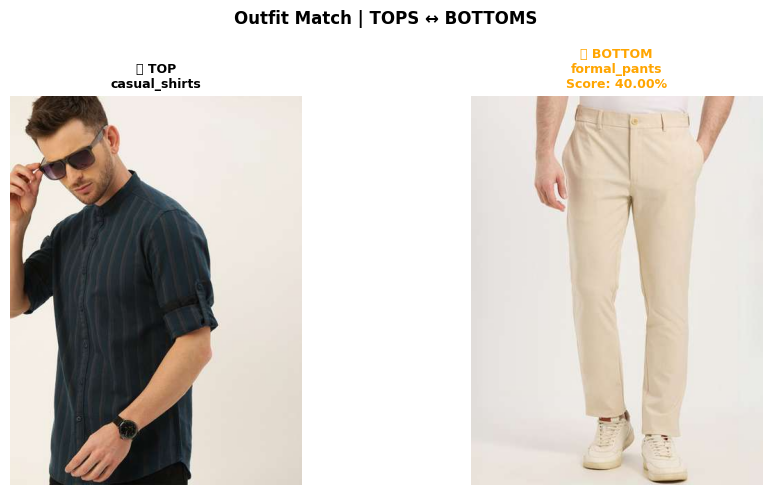

Input    : ../../../fashion_images/dataset_clean/casual_shirts/img_0381.jpg
Matched  : ../../../fashion_images/dataset_clean/formal_pants/img_0969.jpg
Score    : 40.00%


In [60]:
from difflib import SequenceMatcher
import os
import random

# Buikd fast lookup: filename -> (Category, Subcategory, Full Path)
lookup = {
    Path(str(r['image_path'])).name: r for _, r in df_merged.drop_duplicates(subset=['image_path']).iterrows()
}

def match_outfit(image_path, df_merged):
    input_name = Path(str(image_path)).name
    input_row = lookup.get(input_name)

    if input_row is None:
        print(f"Image {input_name} not found in dataset.")

    input_category = str(input_row['category']).lower()
    input_subcategory = str(input_row['subcategory']).lower()
    target_category = 'bottoms' if input_category == 'tops' else 'tops'

    # Filter opposite category & score
    df_opp = df_merged[df_merged['category'].str.lower() == target_category]
    df_opp = df_opp.assign(score=df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcategory, str(s).lower()).ratio()
    ))
    best = df_opp.loc[df_opp['score'].idxmax()]
    percentage = best['score'] * 100

    # Display
    color = 'green' if percentage > 70 else 'orange' if percentage >= 40 else 'red'
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(image_path));         axes[0].axis('off')
    axes[0].set_title(f"{'👕 TOP' if input_category=='tops' else '👖 BOTTOM'}\n{input_subcategory}", fontsize=9, fontweight='bold')
    axes[1].imshow(Image.open(best['image_path'])); axes[1].axis('off')
    axes[1].set_title(f"{'👖 BOTTOM' if input_category=='tops' else '👕 TOP'}\n{best['subcategory']}\nScore: {percentage:.2f}%", fontsize=9, color=color, fontweight='bold')
    plt.suptitle(f"Outfit Match | {input_category.upper()} ↔ {target_category.upper()}", fontweight='bold')
    plt.tight_layout(); plt.show()

    return best, best['score']

# Example usage
PATH_IMAGES = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best, score = match_outfit(test_image_path, df_merged)
print(f"Input    : {test_image_path}")
print(f"Matched  : {best['image_path']}")
print(f"Score    : {score * 100:.2f}%")

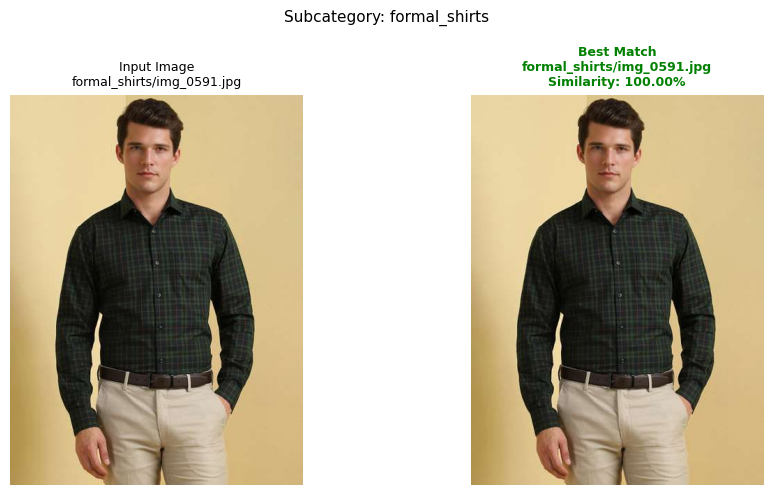

Input      : ../../../fashion_images/dataset_clean/formal_shirts/img_0591.jpg
Best match : ../../../fashion_images/dataset_clean/formal_shirts/img_0591.jpg
Subcategory: formal_shirts
Similarity : 100.00%


In [61]:
from difflib import SequenceMatcher
from pathlib import Path
import os, random

def image_path_similarity(image_path, df_merged):
    """Match input image against df_merged using FULL path (folder + filename)"""
    best_match    = None
    highest_ratio = 0

    input_path   = str(image_path)
    input_folder = Path(image_path).parent.name   # e.g. 'formal_shirts'
    input_name   = Path(image_path).name           # e.g. 'img_1169.jpg'

    for _, row in df_merged.iterrows():
        df_path   = str(row['image_path'])
        df_folder = Path(df_path).parent.name      # e.g. 'formal_shirts'
        df_name   = Path(df_path).name             # e.g. 'img_1169.jpg'

        # ── Match: folder (subcategory) + filename BOTH must align ──
        ratio_folder = SequenceMatcher(None, input_folder, df_folder).ratio()
        ratio_name   = SequenceMatcher(None, input_name,   df_name).ratio()

        # Weight folder match higher to avoid cross-category false positives
        weighted = (ratio_folder * 0.7) + (ratio_name * 0.3)

        if weighted > highest_ratio:
            highest_ratio = weighted
            best_match    = row

    # ── Display ───────────────────────────────────────────────
    if best_match is not None:
        score = highest_ratio * 100
        color = 'green' if score >= 70 else 'orange' if score >= 40 else 'red'

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(Image.open(image_path))
        axes[0].set_title(
            f"Input Image\n{input_folder}/{input_name}",
            fontsize=9
        )
        axes[0].axis('off')

        axes[1].imshow(Image.open(best_match['image_path']))
        axes[1].set_title(
            f"Best Match\n{Path(best_match['image_path']).parent.name}/{Path(best_match['image_path']).name}\n"
            f"Similarity: {score:.2f}%",
            fontsize=9, color=color, fontweight='bold'
        )
        axes[1].axis('off')

        plt.suptitle(f"Subcategory: {best_match['subcategory']}", fontsize=11)
        plt.tight_layout()
        plt.show()

    return best_match, highest_ratio


# ── Example usage ─────────────────────────────────────────────
PATH_IMAGES     = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best_match, similarity = image_path_similarity(test_image_path, df_merged)
print(f"Input      : {test_image_path}")
print(f"Best match : {best_match['image_path']}")
print(f"Subcategory: {best_match['subcategory']}")
print(f"Similarity : {similarity * 100:.2f}%")

In [62]:
df_images

,item_id,category,subcategory,sleeve_type,season,fabric,occasion,formality_level,size_range,brand,view_count,click_count,purchase_count,length_cm,price,stocks,item_id_str,idx_within_subcat,image_path
0,TNC_000001,bottoms,men_cargos,long,winter,polyester,casual,high,S,Tommy Hilfiger,93,192,4,97,262476,35,TNC_000001,0,../fashion_images/dataset_clean/men_cargos/img...
1,TNC_000002,tops,formal_shirts,long,winter,linen,party,medium,S,HnM,2941,84,5,77,266987,182,TNC_000002,0,../fashion_images/dataset_clean/formal_shirts/...
2,TNC_000003,tops,formal_shirts,long,winter,denim,party,high,XL,HnM,401,434,35,71,286065,32,TNC_000003,1,../fashion_images/dataset_clean/formal_shirts/...
3,TNC_000004,tops,printed_tshirts,short,all-season,linen,office,low,XXL,Tommy Hilfiger,318,85,101,70,153376,149,TNC_000004,0,../fashion_images/dataset_clean/printed_tshirt...
4,TNC_000005,tops,formal_shirts,long,all-season,polyester,casual,low,L,ZARA,857,153,67,69,323155,43,TNC_000005,2,../fashion_images/dataset_clean/formal_shirts/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,TNC_1099996,tops,solid_tshirts,short,summer,polyester,party,medium,M,HnM,2924,183,2,73,140786,163,TNC_1099996,109772,../fashion_images/dataset_clean/solid_tshirts/...
1099996,TNC_1099997,bottoms,formal_pants,long,summer,denim,party,high,XXL,Polo,2362,94,32,95,353863,198,TNC_1099997,183895,../fashion_images/dataset_clean/formal_pants/i...
1099997,TNC_1099998,bottoms,men_cargos,long,winter,fleece,casual,low,M,Adidas,617,147,39,97,299627,78,TNC_1099998,183289,../fashion_images/dataset_clean/men_cargos/img...
1099998,TNC_1099999,tops,solid_tshirts,short,summer,cotton,office,low,XXL,Tommy Hilfiger,326,0,25,71,153123,172,TNC_1099999,109773,../fashion_images/dataset_clean/solid_tshirts/...


Input: ../../../fashion_images/dataset_clean/formal_pants/img_0019.jpg



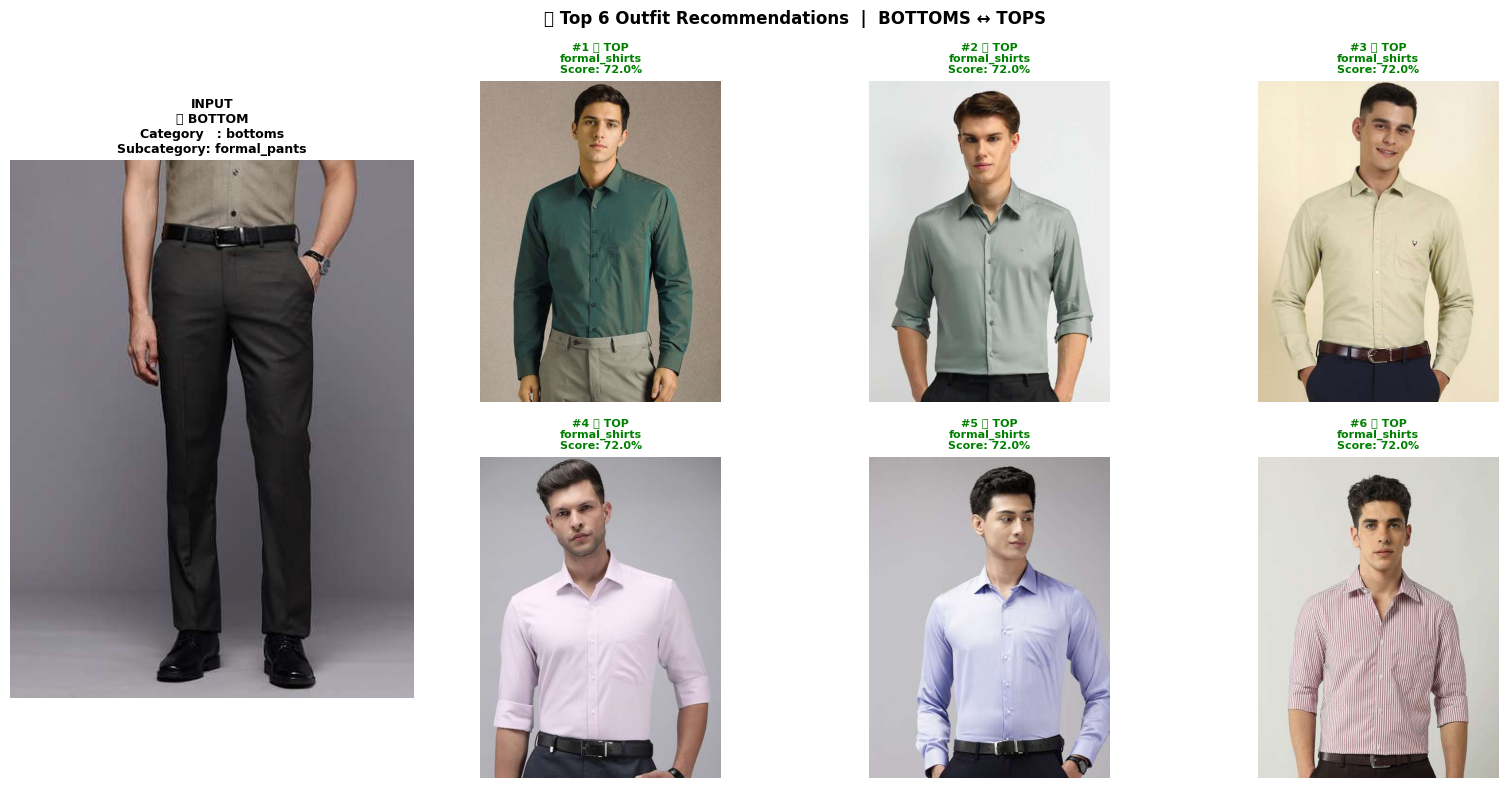


Input       : img_0019.jpg
Category    : bottoms  →  Recommending: tops
Subcategory : formal_pants
#1  formal_shirts             Score: 72.0%  |  img_0969.jpg
#2  formal_shirts             Score: 72.0%  |  img_0955.jpg
#3  formal_shirts             Score: 72.0%  |  img_0799.jpg
#4  formal_shirts             Score: 72.0%  |  img_0941.jpg
#5  formal_shirts             Score: 72.0%  |  img_0772.jpg
#6  formal_shirts             Score: 72.0%  |  img_0014.jpg


In [70]:
from difflib import SequenceMatcher
from pathlib import Path
import random

# ── Build lookup: (folder/filename) → row ────────────────────
lookup = {
    f"{Path(str(r['image_path'])).parent.name}/{Path(str(r['image_path'])).name}": r
    for _, r in df_merged.drop_duplicates('image_path').iterrows()
}

def recommend_outfit(image_path, df_merged, top_n=6):
    image_path   = Path(str(image_path))          # ✅ accept string or Path
    input_key    = f"{image_path.parent.name}/{image_path.name}"
    input_row    = lookup.get(input_key)

    if input_row is None:
        print(f"⚠️ Not found in lookup: {input_key}"); return
    if not image_path.exists():
        print(f"⚠️ File not found on disk: {image_path}"); return

    input_cat    = str(input_row['category']).lower()
    input_subcat = str(input_row['subcategory']).lower()
    target_cat   = 'bottoms' if input_cat == 'tops' else 'tops'

    # ── Score opposite category ───────────────────────────────
    df_opp = df_merged[df_merged['category'].str.lower() == target_cat].copy()
    df_opp = df_opp.drop_duplicates('image_path')
    df_opp['score'] = df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcat, str(s).lower()).ratio()
    )
    df_opp = df_opp[df_opp['image_path'].apply(lambda p: Path(str(p)).exists())]
    top6   = df_opp.nlargest(top_n, 'score')

    # ── Plot ──────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 8))

    ax_input = fig.add_subplot(2, 4, (1, 5))
    ax_input.imshow(Image.open(image_path))
    ax_input.axis('off')
    ax_input.set_title(
        f"INPUT\n{'👕 TOP' if input_cat == 'tops' else '👖 BOTTOM'}\n"
        f"Category   : {input_cat}\n"
        f"Subcategory: {input_subcat}",
        fontsize=9, fontweight='bold'
    )

    for i, (_, row) in enumerate(top6.iterrows()):
        pct   = row['score'] * 100
        color = 'green' if pct >= 70 else 'orange' if pct >= 40 else 'red'
        ax    = fig.add_subplot(2, 4, [2, 3, 4, 6, 7, 8][i])
        ax.imshow(Image.open(row['image_path']))
        ax.axis('off')
        ax.set_title(
            f"#{i+1} {'👖 BOTTOM' if input_cat=='tops' else '👕 TOP'}\n"
            f"{row['subcategory']}\nScore: {pct:.1f}%",
            fontsize=8, color=color, fontweight='bold'
        )

    plt.suptitle(f"👗 Top {top_n} Outfit Recommendations  |  {input_cat.upper()} ↔ {target_cat.upper()}", fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\n{'='*50}")
    print(f"Input       : {image_path.name}")
    print(f"Category    : {input_cat}  →  Recommending: {target_cat}")
    print(f"Subcategory : {input_subcat}")
    print(f"{'='*50}")
    for i, (_, row) in enumerate(top6.iterrows()):
        print(f"#{i+1}  {row['subcategory']:<25} Score: {row['score']*100:.1f}%  |  {Path(str(row['image_path'])).name}")

    return top6


# ── Usage: pass INPUT_IMAGE as string ────────────────────────
INPUT_IMAGE = "../../../fashion_images/dataset_clean/formal_pants/img_0019.jpg"

print(f"Input: {INPUT_IMAGE}\n")
top6 = recommend_outfit(INPUT_IMAGE, df_merged, top_n=6)

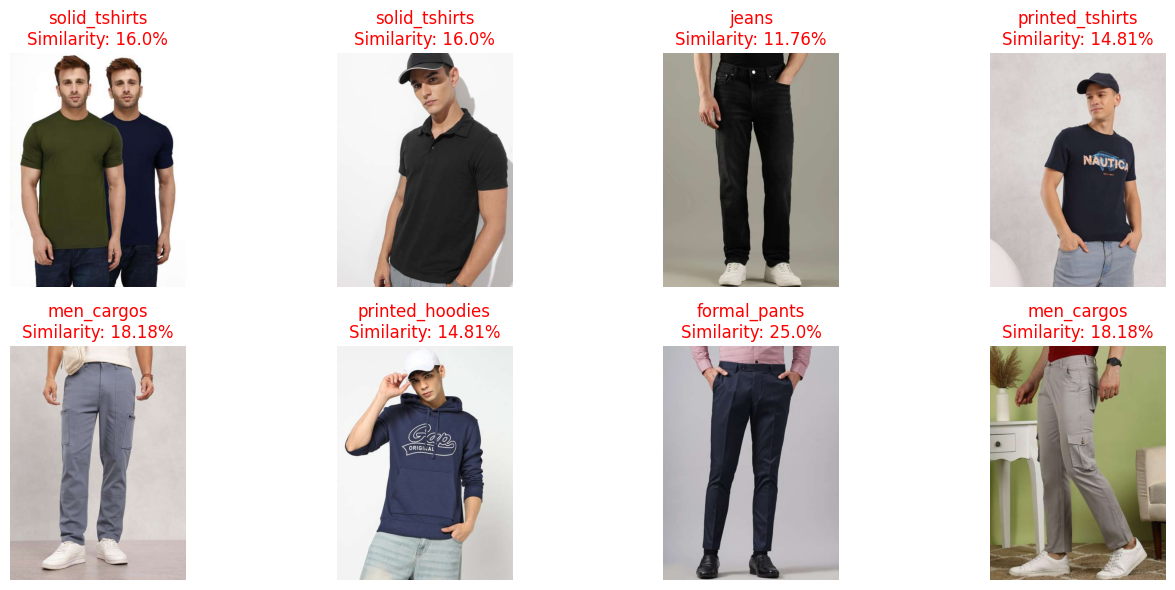

In [64]:
# Compute similarity scores % per row
df_merged['similarity'] = df_merged.apply(
    lambda row: round(
        SequenceMatcher(None, 
            os.path.basename(str(row['image_path'])), 
            str(row['subcategory'])
        ).ratio() * 100, 2
    ), axis=1
)

# Show random images from dataframe
def show_random_images_from_df_merged(df_merged, n=8, cols=4, figsize=(14, 6)):
    selected = df_merged.dropna(subset=['image_path']).sample(n)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, (_, row) in enumerate(selected.iterrows()):
        sim = row['similarity']
        color = 'green' if sim >= 70 else 'orange' if sim >= 40 else 'red'
        plt.subplot(rows, cols, i + 1)
        plt.imshow(Image.open(row['image_path']))
        plt.title(f"{row['subcategory']}\nSimilarity: {sim}%", color=color, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage call to display random images from merged dataframe
show_random_images_from_df_merged(df_merged, n=8)

## AI Engineering structure project concept and goals achieved
* ### Experiment in Notebook → Stabilize → Move to Python services → Expose API

## Finetuning LLM